# RNN Decoder — Experiments & Evaluation

Evaluasi 6 variasi SimpleRNN decoder pada Flickr8k test set. Mencakup:
- BLEU-4 dan METEOR tiap variasi
- Perbandingan Keras vs from-scratch
- Analisis pengaruh jumlah layer & hidden state
- Qualitative analysis 10 gambar
- Pengaruh panjang maksimum caption

In [1]:
import os, sys, json, pickle, time, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import nltk
from pathlib import Path


def _find_root(marker='requirements.txt'):
    p = Path(os.getcwd())
    while p != p.parent:
        if (p / marker).exists():
            return p
        p = p.parent
    raise RuntimeError('Repo root not found')


REPO_ROOT = _find_root()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / 'src'))

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import tensorflow as tf
from tensorflow import keras
from shared.caption_utils import clean_caption, load_vocabulary
from shared.metrics import bleu4, meteor
from rnn.model import RNNDecoder
from rnn.train_keras import build_rnn_decoder

print('TF:', tf.__version__, ' | root:', REPO_ROOT)

/Users/ziyanagil/Agil/Semester 08/IF3270 Pembelajaran Mesin/Tubes 2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF: 2.16.2  | root: /Users/ziyanagil/Agil/Semester 08/IF3270 Pembelajaran Mesin/Tubes 2/CNN-RNN-digaspolndangakndangak


## Config

In [2]:
FEATURE_DIM  = 2048
EMBED_DIM    = 256
MAX_SEQ_LEN  = 34
MAX_CAP_LEN  = 30

FEATURES_NPY  = 'features/flickr8k_features.npy'
VOCAB_JSON    = 'features/vocab.json'
IDX_JSON      = 'features/flickr8k_idx.json'
SPLITS_JSON   = 'features/splits.json'
CAPTIONS_TXT  = 'data/flickr8k/captions.txt'
IMAGES_DIR    = 'data/flickr8k/Images'
MODELS_DIR    = 'models/rnn'
HISTORY_DIR   = 'models/rnn/history'

VARIATIONS = [
    {'name': 'rnn-1layer-128', 'num_rnn_layers': 1, 'rnn_units': 128},
    {'name': 'rnn-2layer-128', 'num_rnn_layers': 2, 'rnn_units': 128},
    {'name': 'rnn-3layer-128', 'num_rnn_layers': 3, 'rnn_units': 128},
    {'name': 'rnn-1layer-512', 'num_rnn_layers': 1, 'rnn_units': 512},
    {'name': 'rnn-2layer-512', 'num_rnn_layers': 2, 'rnn_units': 512},
    {'name': 'rnn-3layer-512', 'num_rnn_layers': 3, 'rnn_units': 512},
]

## Load resources

In [3]:
features  = np.load(FEATURES_NPY)
vocab     = load_vocabulary(VOCAB_JSON)
idx2word  = {v: k for k, v in vocab.items()}
VOCAB_SIZE = len(vocab)

with open(IDX_JSON)    as f: idx_map = json.load(f)
with open(SPLITS_JSON) as f: splits  = json.load(f)

caption_map = {}
with open(CAPTIONS_TXT) as f:
    next(f)
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(',', 1)
        if len(parts) != 2:
            continue
        img_file, caption = parts
        img_id = os.path.splitext(img_file)[0]
        caption_map.setdefault(img_id, []).append(caption)

test_ids = splits['test']

test_refs = [
    [clean_caption(c).split() for c in caption_map[img_id]]
    for img_id in test_ids
]

print(f'Vocab: {VOCAB_SIZE} | Features: {features.shape} | Test: {len(test_ids)}')

Vocab: 7684 | Features: (8091, 2048) | Test: 1091


## Helper functions

In [4]:
@tf.function(reduce_retracing=True)
def _model_call(model, feats, caps):
    return model([feats, caps], training=False)


def _greedy_one_batch(model, feat_vecs_batch, vocab, idx2word, max_len):
    N         = len(feat_vecs_batch)
    start_idx = vocab['<start>']
    end_idx   = vocab['<end>']
    pad_idx   = vocab['<pad>']

    feats = tf.constant(np.array(feat_vecs_batch, dtype=np.float32))
    caps  = np.full((N, MAX_SEQ_LEN), pad_idx, dtype=np.int32)
    caps[:, 0] = start_idx

    word_lists = [[] for _ in range(N)]
    finished   = np.zeros(N, dtype=bool)

    for t in range(min(max_len, MAX_SEQ_LEN)):
        preds  = _model_call(model, feats, tf.constant(caps)).numpy()
        tokens = np.argmax(preds[:, t, :], axis=-1)

        for i, tok in enumerate(tokens):
            if finished[i]:
                continue
            if tok == end_idx:
                finished[i] = True
            else:
                word_lists[i].append(idx2word.get(int(tok), '<unk>'))
            if t + 1 < MAX_SEQ_LEN:
                caps[i, t + 1] = tok

        if finished.all():
            break

    return [' '.join(wl) for wl in word_lists]


def keras_greedy_batch(model, feat_vecs, vocab, idx2word, max_len=MAX_CAP_LEN, batch_size=64):
    captions = []
    for start in range(0, len(feat_vecs), batch_size):
        chunk = feat_vecs[start : start + batch_size]
        captions.extend(_greedy_one_batch(model, chunk, vocab, idx2word, max_len))
    return captions


def compute_scores(hypotheses, references):
    hyp_tokens = [h.split() for h in hypotheses]
    b4  = bleu4(references, hyp_tokens)
    met = meteor(references, hyp_tokens)
    return b4, met

## Load training histories

In [5]:
histories = {}
for pkl_path in sorted(glob.glob(os.path.join(HISTORY_DIR, '*.pkl'))):
    name = os.path.splitext(os.path.basename(pkl_path))[0]
    with open(pkl_path, 'rb') as f:
        histories[name] = pickle.load(f)

print('Loaded histories:', sorted(histories.keys()))

Loaded histories: ['rnn-1layer-128', 'rnn-1layer-512', 'rnn-2layer-128', 'rnn-2layer-512', 'rnn-3layer-128', 'rnn-3layer-512']


## Training & Validation Loss Curves

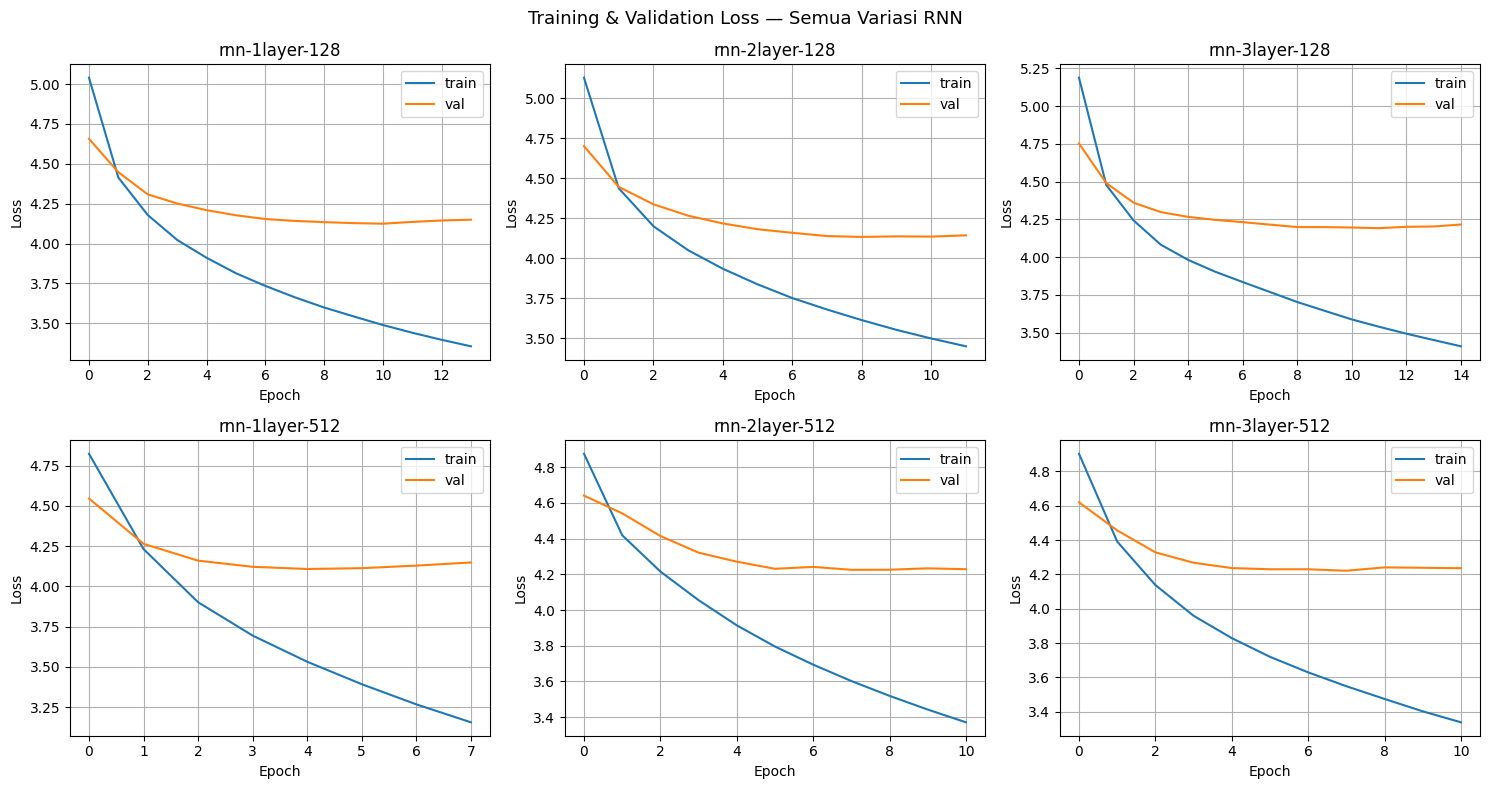

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, cfg in enumerate(VARIATIONS):
    name = cfg['name']
    h    = histories[name]['history']
    ax   = axes[i]
    ax.plot(h['loss'],     label='train')
    ax.plot(h['val_loss'], label='val')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

plt.suptitle('Training & Validation Loss — Semua Variasi RNN', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'loss_curves_rnn.png'), dpi=120)
plt.show()

## Evaluasi Semua Variasi

Untuk setiap variasi: jalankan greedy decoding dengan Keras dan from-scratch, lalu hitung BLEU-4 & METEOR.

In [7]:
test_feat_vecs = [features[idx_map[img_id]] for img_id in test_ids]

results = {}

for cfg in VARIATIONS:
    name       = cfg['name']
    model_path = os.path.join(MODELS_DIR, f'{name}.keras')
    print(f'\n{"="*55}\n{name}\n{"="*55}')

    keras_model = build_rnn_decoder(
        vocab_size=VOCAB_SIZE,
        feature_dim=FEATURE_DIM,
        embed_dim=EMBED_DIM,
        rnn_units=cfg['rnn_units'],
        num_rnn_layers=cfg['num_rnn_layers'],
    )
    keras_model.load_weights(model_path)

    # Keras inference
    t0          = time.time()
    keras_caps  = keras_greedy_batch(keras_model, test_feat_vecs, vocab, idx2word)
    keras_time  = time.time() - t0
    k_bleu, k_meteor = compute_scores(keras_caps, test_refs)
    print(f'  Keras  | BLEU-4: {k_bleu:.4f}  METEOR: {k_meteor:.4f}  time: {keras_time:.1f}s')

    # From-scratch inference
    decoder = RNNDecoder()
    decoder.load_weights(keras_model, vocab)

    t0           = time.time()
    scratch_caps = [decoder.generate_caption(fv, max_len=MAX_CAP_LEN)
                    for fv in test_feat_vecs]
    scratch_time = time.time() - t0
    s_bleu, s_meteor = compute_scores(scratch_caps, test_refs)
    print(f'  Scratch| BLEU-4: {s_bleu:.4f}  METEOR: {s_meteor:.4f}  time: {scratch_time:.1f}s')

    results[name] = {
        'config': cfg,
        'keras':  {
            'captions': keras_caps,
            'bleu4': k_bleu, 'meteor': k_meteor,
            'time_total': keras_time,
            'time_per_img': keras_time / len(test_ids),
        },
        'scratch': {
            'captions': scratch_caps,
            'bleu4': s_bleu, 'meteor': s_meteor,
            'time_total': scratch_time,
            'time_per_img': scratch_time / len(test_ids),
        },
    }

# simpan supaya bisa dipakai notebook lain
os.makedirs('features', exist_ok=True)
with open('features/rnn_eval_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print('\nResults saved.')


rnn-1layer-128


2026-05-15 18:06:16.192840: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-15 18:06:16.192892: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-15 18:06:16.192899: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-15 18:06:16.193045: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-15 18:06:16.193058: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-15 18:06:16.703380: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Keras  | BLEU-4: 0.0747  METEOR: 0.2326  time: 24.5s
  Scratch| BLEU-4: 0.0039  METEOR: 0.1776  time: 1.4s

rnn-2layer-128
  Keras  | BLEU-4: 0.0544  METEOR: 0.2189  time: 39.9s
  Scratch| BLEU-4: 0.0027  METEOR: 0.1738  time: 1.6s

rnn-3layer-128
  Keras  | BLEU-4: 0.0588  METEOR: 0.2192  time: 52.5s
  Scratch| BLEU-4: 0.0027  METEOR: 0.1603  time: 1.7s

rnn-1layer-512
  Keras  | BLEU-4: 0.0888  METEOR: 0.2431  time: 26.0s
  Scratch| BLEU-4: 0.0033  METEOR: 0.1783  time: 6.3s

rnn-2layer-512
  Keras  | BLEU-4: 0.1059  METEOR: 0.2670  time: 51.2s
  Scratch| BLEU-4: 0.0035  METEOR: 0.1494  time: 10.3s

rnn-3layer-512
  Keras  | BLEU-4: 0.0899  METEOR: 0.2428  time: 67.4s
  Scratch| BLEU-4: 0.0039  METEOR: 0.1661  time: 11.3s

Results saved.


## Tabel Hasil

In [8]:
import pandas as pd

rows = []
for cfg in VARIATIONS:
    name = cfg['name']
    r    = results[name]
    hist = histories[name]
    rows.append({
        'Model':          name,
        'Layers':         cfg['num_rnn_layers'],
        'Units':          cfg['rnn_units'],
        'Best val_loss':  round(min(hist['history']['val_loss']), 4),
        'Train time (s)': round(hist['train_time_sec'], 0),
        'Keras BLEU-4':   round(r['keras']['bleu4'],    4),
        'Keras METEOR':   round(r['keras']['meteor'],   4),
        'Keras inf (s)':  round(r['keras']['time_total'], 1),
        'Scratch BLEU-4': round(r['scratch']['bleu4'],  4),
        'Scratch METEOR': round(r['scratch']['meteor'], 4),
        'Scratch inf (s)':round(r['scratch']['time_total'], 1),
    })

df = pd.DataFrame(rows).set_index('Model')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(df.to_string())
df

                Layers  Units  Best val_loss  Train time (s)  Keras BLEU-4  Keras METEOR  Keras inf (s)  Scratch BLEU-4  Scratch METEOR  Scratch inf (s)
Model                                                                                                                                                   
rnn-1layer-128       1    128         4.1247           770.0        0.0747        0.2326           24.5          0.0039          0.1776              1.4
rnn-2layer-128       2    128         4.1342           689.0        0.0544        0.2189           39.9          0.0027          0.1738              1.6
rnn-3layer-128       3    128         4.1917           934.0        0.0588        0.2192           52.5          0.0027          0.1603              1.7
rnn-1layer-512       1    512         4.1082          1259.0        0.0888        0.2431           26.0          0.0033          0.1783              6.3
rnn-2layer-512       2    512         4.2254          2078.0        0.1059        

,Layers,Units,Best val_loss,Train time (s),Keras BLEU-4,Keras METEOR,Keras inf (s),Scratch BLEU-4,Scratch METEOR,Scratch inf (s)
Model,,,,,,,,,,
rnn-1layer-128,1,128,4.1247,770.0,0.0747,0.2326,24.5,0.0039,0.1776,1.4
rnn-2layer-128,2,128,4.1342,689.0,0.0544,0.2189,39.9,0.0027,0.1738,1.6
rnn-3layer-128,3,128,4.1917,934.0,0.0588,0.2192,52.5,0.0027,0.1603,1.7
rnn-1layer-512,1,512,4.1082,1259.0,0.0888,0.2431,26.0,0.0033,0.1783,6.3
rnn-2layer-512,2,512,4.2254,2078.0,0.1059,0.2670,51.2,0.0035,0.1494,10.3
rnn-3layer-512,3,512,4.2214,2389.0,0.0899,0.2428,67.4,0.0039,0.1661,11.3


## Analisis Pengaruh Jumlah Layer

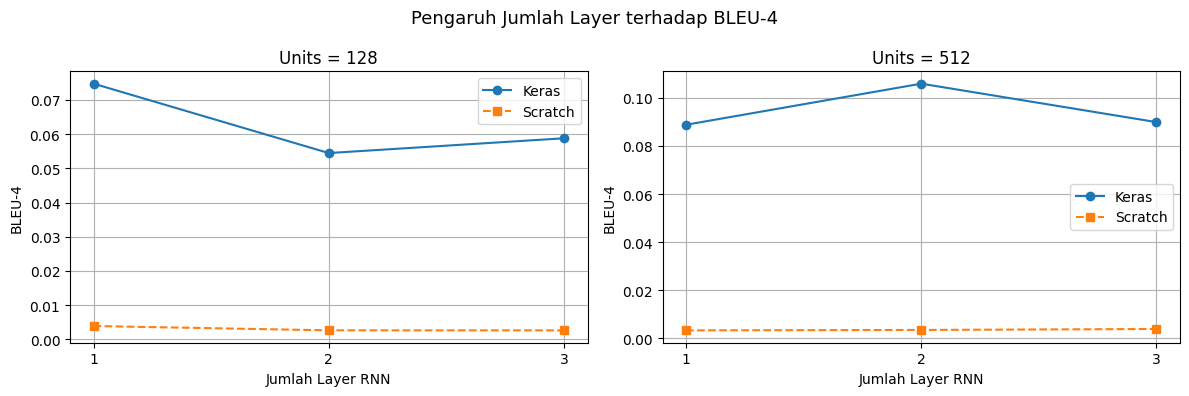

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, units in zip(axes, [128, 512]):
    layer_counts = [1, 2, 3]
    keras_b4   = [results[f'rnn-{l}layer-{units}']['keras']['bleu4']   for l in layer_counts]
    scratch_b4 = [results[f'rnn-{l}layer-{units}']['scratch']['bleu4'] for l in layer_counts]
    ax.plot(layer_counts, keras_b4,   'o-', label='Keras')
    ax.plot(layer_counts, scratch_b4, 's--', label='Scratch')
    ax.set_title(f'Units = {units}')
    ax.set_xlabel('Jumlah Layer RNN')
    ax.set_ylabel('BLEU-4')
    ax.set_xticks(layer_counts)
    ax.legend()
    ax.grid(True)

plt.suptitle('Pengaruh Jumlah Layer terhadap BLEU-4', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'bleu4_vs_layers.png'), dpi=120)
plt.show()

## Analisis Pengaruh Ukuran Hidden State

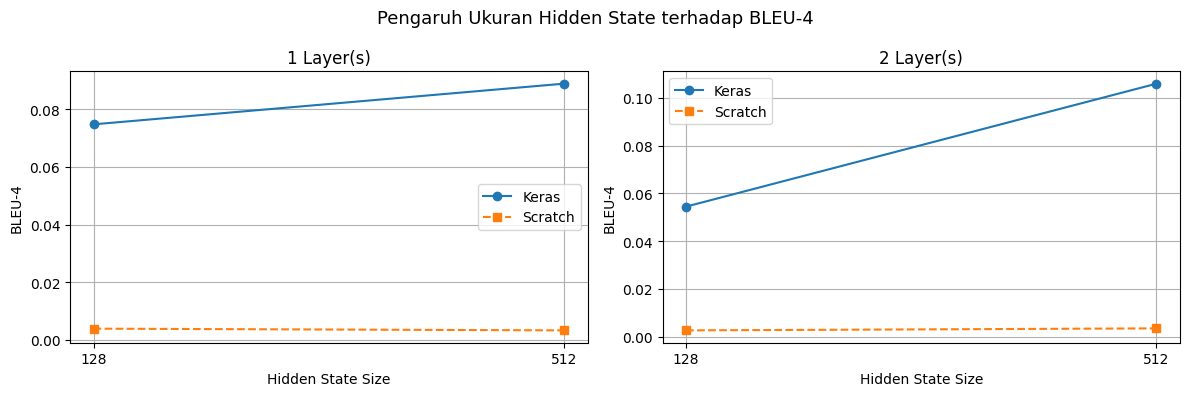

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, n_layers in zip(axes, [1, 2]):
    unit_sizes = [128, 512]
    keras_b4   = [results[f'rnn-{n_layers}layer-{u}']['keras']['bleu4']   for u in unit_sizes]
    scratch_b4 = [results[f'rnn-{n_layers}layer-{u}']['scratch']['bleu4'] for u in unit_sizes]
    ax.plot(unit_sizes, keras_b4,   'o-', label='Keras')
    ax.plot(unit_sizes, scratch_b4, 's--', label='Scratch')
    ax.set_title(f'{n_layers} Layer(s)')
    ax.set_xlabel('Hidden State Size')
    ax.set_ylabel('BLEU-4')
    ax.set_xticks(unit_sizes)
    ax.legend()
    ax.grid(True)

plt.suptitle('Pengaruh Ukuran Hidden State terhadap BLEU-4', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'bleu4_vs_units.png'), dpi=120)
plt.show()

## Perbandingan Keras vs From-Scratch (Best Model)

Best model dipilih berdasarkan BLEU-4 Keras tertinggi.

Best model: rnn-2layer-512
  Keras   — BLEU-4: 0.1059  METEOR: 0.2670  time: 51.2s  (47.0 ms/img)
  Scratch — BLEU-4: 0.0035  METEOR: 0.1494  time: 10.3s  (9.5 ms/img)


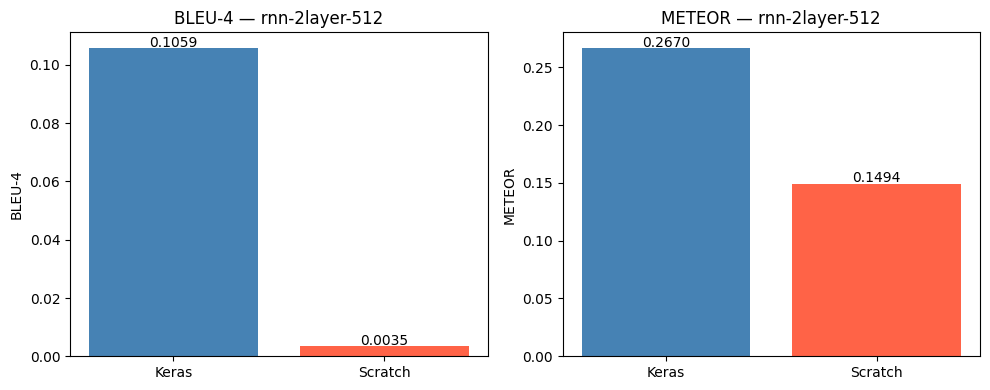

In [11]:
best_name = max(results, key=lambda n: results[n]['keras']['bleu4'])
best      = results[best_name]
print(f'Best model: {best_name}')
print(f'  Keras   — BLEU-4: {best["keras"]["bleu4"]:.4f}  METEOR: {best["keras"]["meteor"]:.4f}  '
      f'time: {best["keras"]["time_total"]:.1f}s  ({best["keras"]["time_per_img"]*1000:.1f} ms/img)')
print(f'  Scratch — BLEU-4: {best["scratch"]["bleu4"]:.4f}  METEOR: {best["scratch"]["meteor"]:.4f}  '
      f'time: {best["scratch"]["time_total"]:.1f}s  ({best["scratch"]["time_per_img"]*1000:.1f} ms/img)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels   = ['Keras', 'Scratch']
bleu_vals  = [best['keras']['bleu4'],  best['scratch']['bleu4']]
meteor_vals = [best['keras']['meteor'], best['scratch']['meteor']]

axes[0].bar(labels, bleu_vals, color=['steelblue', 'tomato'])
axes[0].set_ylabel('BLEU-4')
axes[0].set_title(f'BLEU-4 — {best_name}')
for i, v in enumerate(bleu_vals):
    axes[0].text(i, v + 0.0003, f'{v:.4f}', ha='center')

axes[1].bar(labels, meteor_vals, color=['steelblue', 'tomato'])
axes[1].set_ylabel('METEOR')
axes[1].set_title(f'METEOR — {best_name}')
for i, v in enumerate(meteor_vals):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'keras_vs_scratch.png'), dpi=120)
plt.show()

## Pengaruh Panjang Maksimum Caption

Dijalankan pada best model (from-scratch), variasi max_len = [10, 20, 30, 40].

max_len= 10 | BLEU-4: 0.0049  METEOR: 0.1535
max_len= 20 | BLEU-4: 0.0041  METEOR: 0.1512
max_len= 30 | BLEU-4: 0.0035  METEOR: 0.1494
max_len= 40 | BLEU-4: 0.0029  METEOR: 0.1479


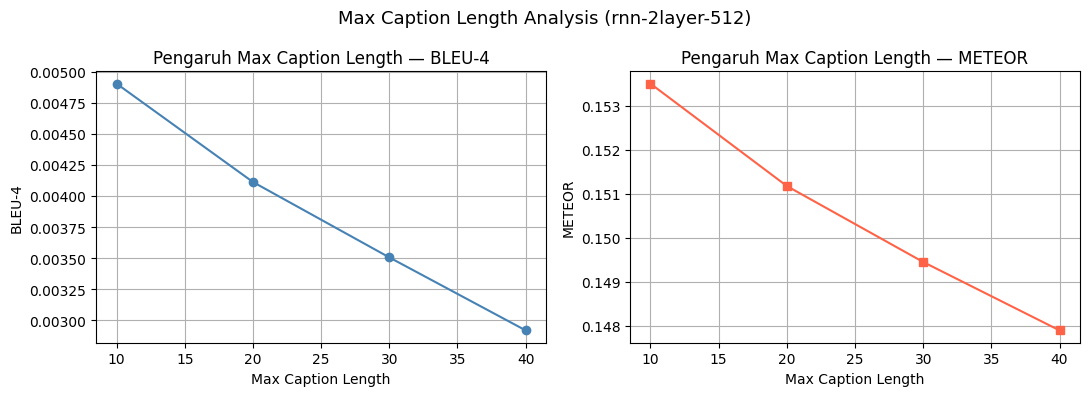

In [12]:
best_cfg = results[best_name]['config']

best_keras = build_rnn_decoder(
    vocab_size=VOCAB_SIZE,
    feature_dim=FEATURE_DIM,
    embed_dim=EMBED_DIM,
    rnn_units=best_cfg['rnn_units'],
    num_rnn_layers=best_cfg['num_rnn_layers'],
)
best_keras.load_weights(os.path.join(MODELS_DIR, f'{best_name}.keras'))

best_decoder = RNNDecoder()
best_decoder.load_weights(best_keras, vocab)

max_len_variations = [10, 20, 30, 40]
maxlen_bleu4  = []
maxlen_meteor = []

for ml in max_len_variations:
    caps = [best_decoder.generate_caption(fv, max_len=ml) for fv in test_feat_vecs]
    hyp_tokens = [c.split() for c in caps]
    b4  = bleu4(test_refs, hyp_tokens)
    met = meteor(test_refs, hyp_tokens)
    maxlen_bleu4.append(b4)
    maxlen_meteor.append(met)
    print(f'max_len={ml:3d} | BLEU-4: {b4:.4f}  METEOR: {met:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(max_len_variations, maxlen_bleu4,  'o-', color='steelblue')
axes[0].set_xlabel('Max Caption Length')
axes[0].set_ylabel('BLEU-4')
axes[0].set_title('Pengaruh Max Caption Length — BLEU-4')
axes[0].grid(True)

axes[1].plot(max_len_variations, maxlen_meteor, 's-', color='tomato')
axes[1].set_xlabel('Max Caption Length')
axes[1].set_ylabel('METEOR')
axes[1].set_title('Pengaruh Max Caption Length — METEOR')
axes[1].grid(True)

plt.suptitle(f'Max Caption Length Analysis ({best_name})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'max_len_analysis.png'), dpi=120)
plt.show()

## Qualitative Analysis — 10 Contoh Gambar

Pilih gambar dengan skor BLEU-4 tinggi, sedang, dan rendah dari best model (scratch).

In [13]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4


def sentence_bleu4(refs, hyp):
    return sentence_bleu(refs, hyp, weights=(0.25,)*4, smoothing_function=smoothie)


scratch_caps = results[best_name]['scratch']['captions']
per_image_scores = [
    sentence_bleu4(test_refs[i], scratch_caps[i].split())
    for i in range(len(test_ids))
]

sorted_indices = np.argsort(per_image_scores)
n = len(sorted_indices)

low_idx    = sorted_indices[:4]
mid_idx    = sorted_indices[n//2 - 2 : n//2 + 2]
high_idx   = sorted_indices[-4:][::-1]

selected = list(high_idx) + list(mid_idx) + list(low_idx)  # 12, pick first 10
selected = selected[:10]

print('Selected image indices:', selected)
print('Scores:', [round(per_image_scores[i], 4) for i in selected])

Selected image indices: [268, 429, 578, 195, 149, 828, 824, 846, 362, 357]
Scores: [0.4315, 0.2786, 0.2008, 0.2, 0.0354, 0.0354, 0.0355, 0.0355, 0, 0]


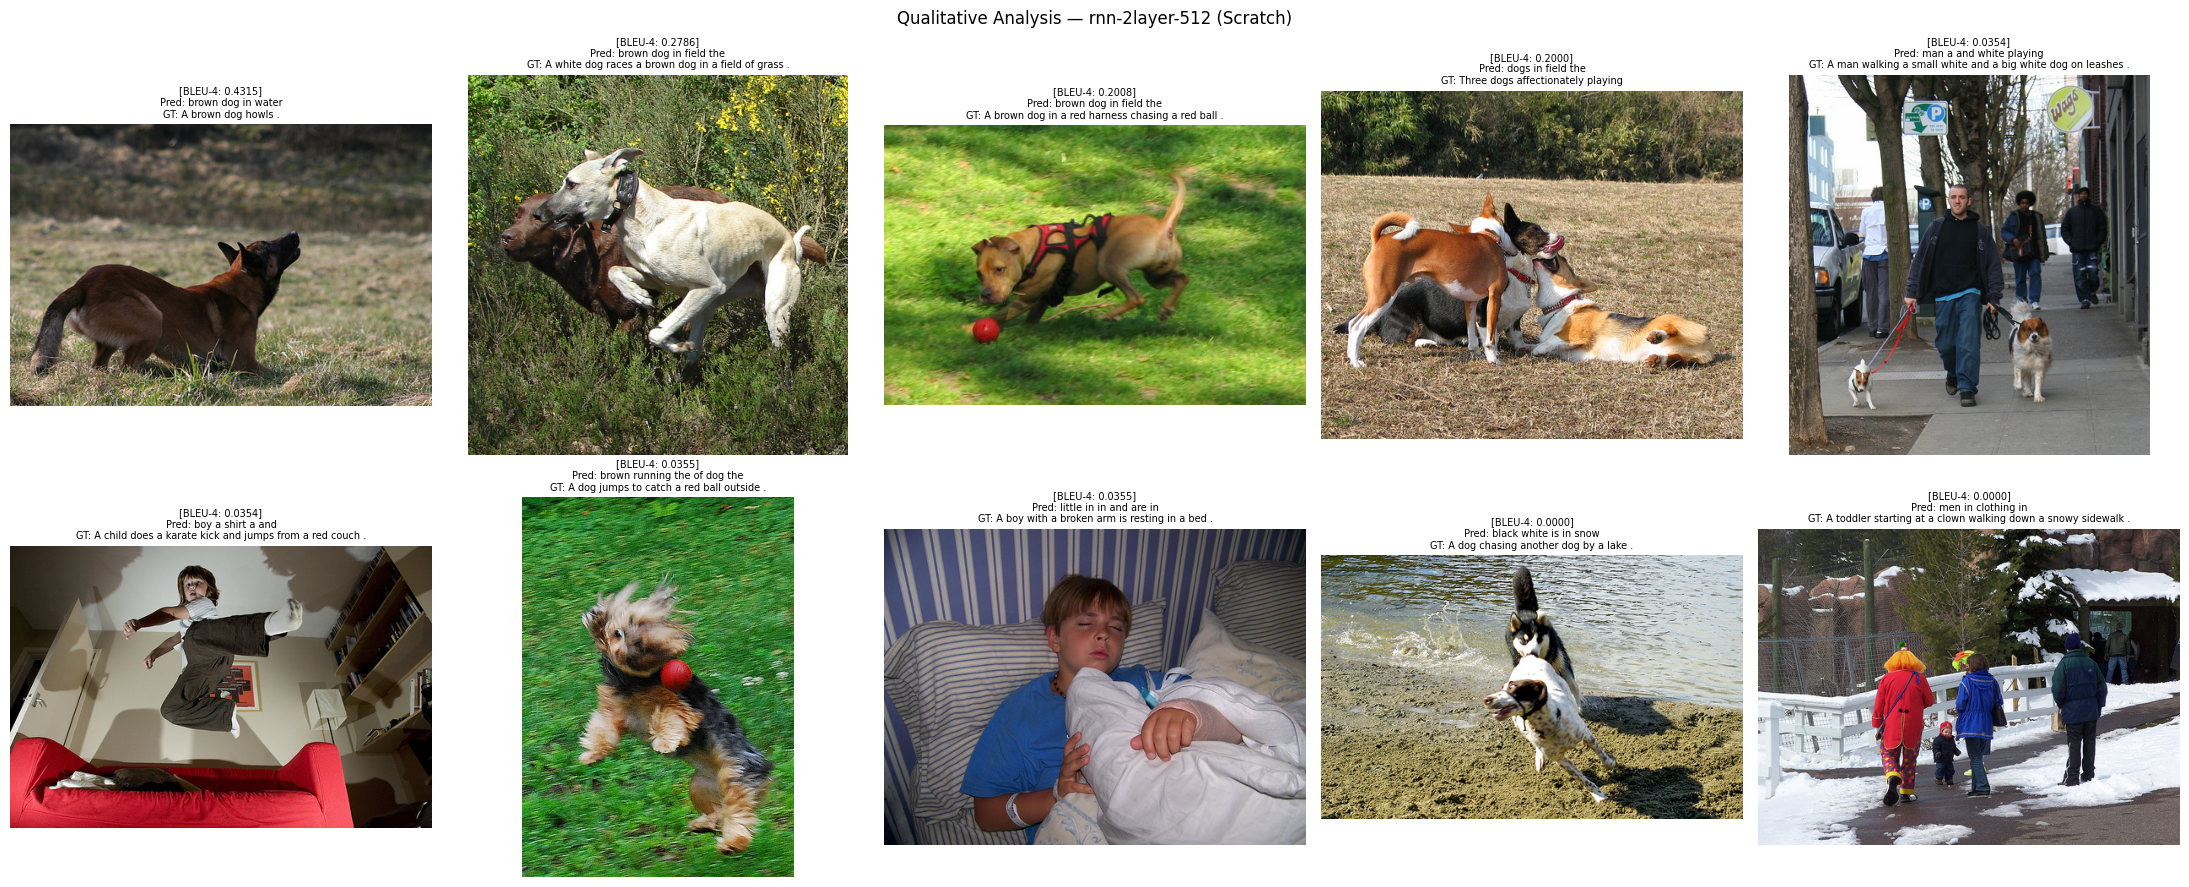

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for plot_i, img_idx in enumerate(selected):
    img_id    = test_ids[img_idx]
    img_path  = os.path.join(IMAGES_DIR, img_id + '.jpg')
    score     = per_image_scores[img_idx]
    pred_cap  = scratch_caps[img_idx]
    gt_caps   = caption_map[img_id]

    ax = axes[plot_i]
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
    ax.axis('off')

    label  = f'[BLEU-4: {score:.4f}]\nPred: {pred_cap}\nGT: {gt_caps[0][:80]}'
    ax.set_title(label, fontsize=7, wrap=True)

plt.suptitle(f'Qualitative Analysis — {best_name} (Scratch)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'qualitative_analysis.png'), dpi=100)
plt.show()

## Ringkasan & Kesimpulan

In [15]:
print('=' * 65)
print('RINGKASAN HASIL EVALUASI RNN DECODER')
print('=' * 65)
print(f'\nBest model: {best_name}')
print(f'  Keras   BLEU-4: {best["keras"]["bleu4"]:.4f}  METEOR: {best["keras"]["meteor"]:.4f}')
print(f'  Scratch BLEU-4: {best["scratch"]["bleu4"]:.4f}  METEOR: {best["scratch"]["meteor"]:.4f}')
print(f'  Speedup Keras vs Scratch: {best["scratch"]["time_total"]/best["keras"]["time_total"]:.2f}x slower')
print()

print('Pengaruh jumlah layer (units=128):')
for l in [1,2,3]:
    n = f'rnn-{l}layer-128'
    print(f'  {n}: BLEU-4={results[n]["keras"]["bleu4"]:.4f}')

print('\nPengaruh ukuran hidden state (1 layer):')
for u in [128, 512]:
    n = f'rnn-1layer-{u}'
    print(f'  {n}: BLEU-4={results[n]["keras"]["bleu4"]:.4f}')

print(f'\nPengaruh max caption length ({best_name}, scratch):')
for ml, b4 in zip(max_len_variations, maxlen_bleu4):
    print(f'  max_len={ml}: BLEU-4={b4:.4f}')

RINGKASAN HASIL EVALUASI RNN DECODER

Best model: rnn-2layer-512
  Keras   BLEU-4: 0.1059  METEOR: 0.2670
  Scratch BLEU-4: 0.0035  METEOR: 0.1494
  Speedup Keras vs Scratch: 0.20x slower

Pengaruh jumlah layer (units=128):
  rnn-1layer-128: BLEU-4=0.0747
  rnn-2layer-128: BLEU-4=0.0544
  rnn-3layer-128: BLEU-4=0.0588

Pengaruh ukuran hidden state (1 layer):
  rnn-1layer-128: BLEU-4=0.0747
  rnn-1layer-512: BLEU-4=0.0888

Pengaruh max caption length (rnn-2layer-512, scratch):
  max_len=10: BLEU-4=0.0049
  max_len=20: BLEU-4=0.0041
  max_len=30: BLEU-4=0.0035
  max_len=40: BLEU-4=0.0029
